In [53]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

%matplotlib widget


In [54]:
condition = "base_model_124"
checkpoint_epoch = 0
n_samples_test = 100
split = "train"
dataset = "biased_00"

In [55]:


# 3mod categorie à part (positioncolor)
# modality_from='attr',
# modality_through='color',
# modality_main=['attr'],
# modality_add='color',

# 4mod normal
# modality_from='cat',
# modality_through='color',
# modality_main=['cat', 'position'],
# modality_add='color',

# 4mod position
# modality_from='cat',
# modality_through='position',
# modality_main=['cat', 'color'],
# modality_add='position',

with total_silence():
    global_workspace, domain_mods, gw_mod, visual_module, original_data, latent_domains, modules_name = get_modules_data_from_exp(experiment_name=condition, n_samples_test=n_samples_test, split=split, checkpoint_epoch=checkpoint_epoch)
    objects = get_objects_from_v_latents(
        latent_domains,
        gw_mod,
        global_workspace,
        modules_name,
        modality_from='attr',
        modality_through='color',
        modality_main=['attr'],
        modality_add='color',
        start_v=False
)

    original_images_rgb = visual_module.decode_images(original_data['v_latents'])

    cat = []
    if 'attr' in modules_name:
        cat = original_data['attr'][0]
    if 'cat' in modules_name:
        cat = original_data['cat']


/home/lucas/gwsyn/syn_project/utils_color_analysis.py:223: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(fig_w, fig_h), dpi=dpi)


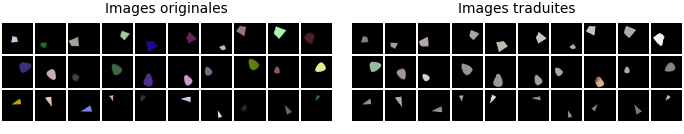

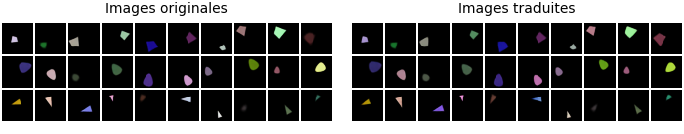

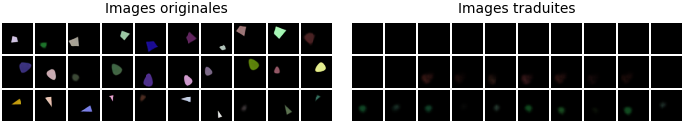

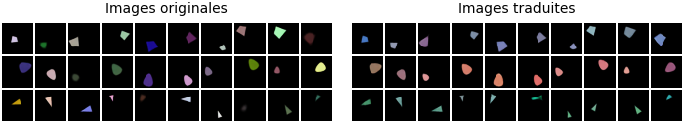

In [56]:
for i in range(1,5):
    decoded_images= visual_module.decode_images(objects[f'vision{i}'])
    fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images, cat, 10))
    plt.show()
    del decoded_images

Accuracy : 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         2

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



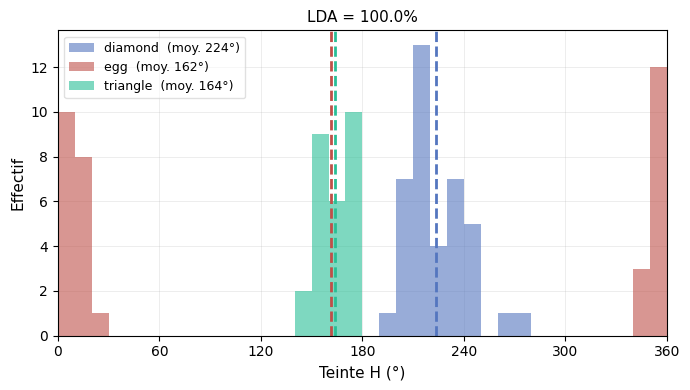

In [57]:
decoded_images= visual_module.decode_images(objects[f'vision4'])
#colors_np = get_samples_rgb({"train_images": None, "images_decoded": decoded_images})
colors_np = objects['x2']['color'].detach().cpu().numpy()
cats = cat.argmax(dim=1).detach().cpu().numpy()

metrics, fig = hue_analysis(colors_np, cats, cat_names=CAT_NAMES, value=0.75, saturation_boost=1.8)

results = logistic_probe(colors_np, cats)
print(f"Accuracy : {results['accuracy']:.2%}")
print(results['report'])

display(fig)

In [58]:
metrics['per_cat']

{0: {'name': 'Cat. 0',
  'mean_hue': 223.55865174228626,
  'std_hue': 17.4024396592766},
 1: {'name': 'Cat. 1',
  'mean_hue': 2.7447704862576137,
  'std_hue': 10.153057822655667},
 2: {'name': 'Cat. 2',
  'mean_hue': 163.77239896963147,
  'std_hue': 9.519353613897591}}

In [59]:
del original_images_rgb
del decoded_images
torch.cuda.empty_cache()